In [228]:
# Ячейка для мгновенного обновления модулей
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [379]:
import numpy as np
import pandas as pd

from dataclasses import dataclass

from Bio import Phylo
from Bio.Phylo.BaseTree import Clade, Tree

from UPGMA import UPGMA, compute_distance_matrix
from NeighborJoining import NeighborJoining

import warnings
warnings.simplefilter('ignore')

In [380]:
sequences = np.array(['ATTTG', 
                      'AGCGT', 
                      'ACCGT', 
                      'CGCGA', 
                      'GGCGA', 
                      'CGGGG'
                      ])

# UPGMA

Tree(rooted=True)
    Clade(branch_length=1)
        Clade(name='ATTTG')
        Clade()
            Clade()
                Clade(name='AGCGT')
                Clade(name='ACCGT')
            Clade()
                Clade(name='CGGGG')
                Clade()
                    Clade(name='CGCGA')
                    Clade(name='GGCGA')


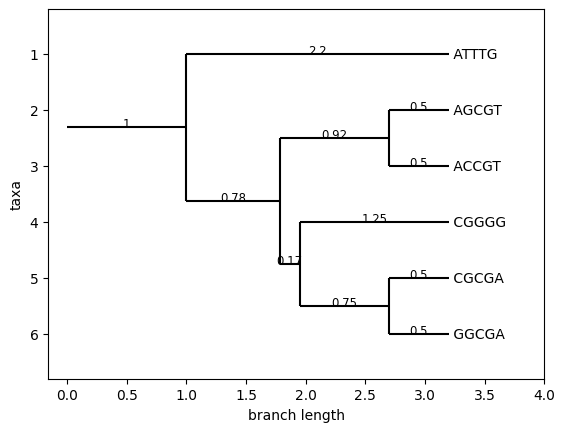

In [381]:
upgma = UPGMA(sequences=sequences)
upgma_tree = upgma.run()

print(upgma_tree)

upgma.draw_tree(upgma_tree)

# NJ

Tree(rooted=False)
    Clade()
        Clade()
            Clade(name='ATTTG')
            Clade(name='CGGGG')
        Clade()
            Clade()
                Clade(name='AGCGT')
                Clade(name='ACCGT')
            Clade()
                Clade(name='CGCGA')
                Clade(name='GGCGA')


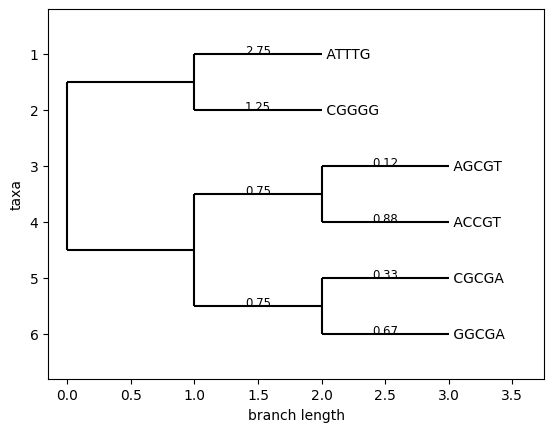

In [382]:
D = compute_distance_matrix(sequences=sequences)

NJ = NeighborJoining(sequences=sequences)
NJ_tree = NJ.run()
print(NJ_tree)

NJ.draw_tree(NJ_tree)

In [383]:
NJ.matrices_history[-1]

,"(ATTTG, CGGGG)","((AGCGT, ACCGT), (CGCGA, GGCGA))"
"(ATTTG, CGGGG)",0.0,0.5
"((AGCGT, ACCGT), (CGCGA, GGCGA))",0.5,0.0


Tree(rooted=False)
    Clade()
        Clade()
            Clade(name='V')
            Clade(name='U')
        Clade()
            Clade()
                Clade(name='X')
                Clade(name='Y')
            Clade()
                Clade(name='Z')
                Clade(name='W')


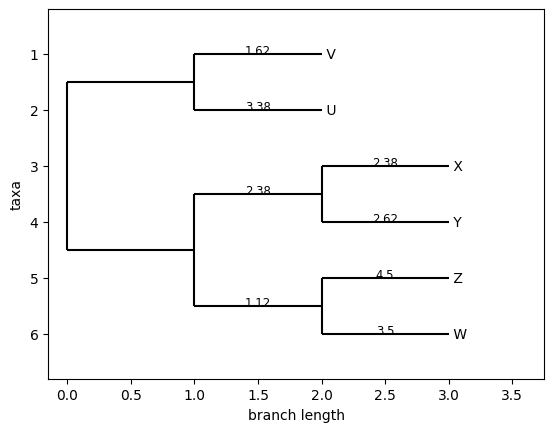

In [384]:
matrix = pd.DataFrame(data = np.array([
    [0, 5, 9, 10, 7, 10],
    [5, 0, 10, 11, 6, 10],
    [9, 10, 0, 8, 10, 9],
    [10, 11, 8, 0, 7, 8],
    [7, 6, 10, 7, 0, 5],
    [10, 10, 9, 8, 5, 0]
    ]), 
    index = ['X', 'Y', 'Z', 'W', 'V', 'U'], 
    columns = ['X', 'Y', 'Z', 'W', 'V', 'U'])


NJ = NeighborJoining(matrix=matrix)
NJ_tree = NJ.run()
print(NJ_tree)

NJ.draw_tree(NJ_tree)

In [385]:
NJ.matrices_history[-1]

,"(V, U)","((X, Y), (Z, W))"
"(V, U)",0.000,0.875
"((X, Y), (Z, W))",0.875,0.000
